In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import idx2numpy

In [ ]:
train_images = idx2numpy.convert_from_file('../MNIST/train-images.idx3-ubyte')
train_labels = idx2numpy.convert_from_file('../MNIST/train-labels.idx1-ubyte')
test_images  = idx2numpy.convert_from_file('../MNIST/t10k-images.idx3-ubyte')
test_labels  = idx2numpy.convert_from_file('../MNIST/t10k-labels.idx1-ubyte')

def select_balanced_samples(images, labels, per_class):
    selected_idx = []
    for digit in range(10):
        idx = np.where(labels == digit)[0]
        chosen = np.random.choice(idx, per_class, replace=False)
        selected_idx.extend(chosen)
    selected_idx = np.array(selected_idx)
    np.random.shuffle(selected_idx)
    return images[selected_idx], labels[selected_idx]

np.random.seed(42)
X_train, y_train = select_balanced_samples(train_images, train_labels, 500)
X_test,  y_test  = select_balanced_samples(test_images,  test_labels,  100)

X_train = X_train.reshape(-1, 784).astype(np.float64) / 255.0
X_test  = X_test.reshape(-1, 784).astype(np.float64)  / 255.0

def encode_labels_tanh(labels, num_classes=10):
    encoded = -1.0 * np.ones((len(labels), num_classes))
    for i, l in enumerate(labels):
        encoded[i, l] = 1.0
    return encoded

Y_train = encode_labels_tanh(y_train)
Y_test  = encode_labels_tanh(y_test)

print(f"Training samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}")
print(f"Input dim: {X_train.shape[1]}  |  Output dim: {Y_train.shape[1]}")

Training samples: 5000  |  Test samples: 1000
Input dim: 784  |  Output dim: 10


In [ ]:
def tanh(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1.0 - a ** 2

n_input  = 784
n_output = 10
scale = np.sqrt(2.0 / (n_input + n_output))

W = np.random.randn(n_output, n_input) * scale
b = np.zeros((n_output, 1))

learning_rate = 0.01
epochs = 10

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    epoch_loss = 0.0
    correct = 0

    perm = np.random.permutation(X_train.shape[0])

    for i in perm:
        x = X_train[i].reshape(-1, 1)
        y = Y_train[i].reshape(-1, 1)

        z = W @ x + b
        a = tanh(z)

        loss = 0.5 * np.sum((a - y) ** 2)
        epoch_loss += loss

        if np.argmax(a) == np.argmax(y):
            correct += 1

        dL_da = a - y
        dL_dz = dL_da * tanh_derivative(a)
        dL_dW = dL_dz @ x.T
        dL_db = dL_dz

        W -= learning_rate * dL_dW
        b -= learning_rate * dL_db

    avg_loss  = epoch_loss / X_train.shape[0]
    train_acc = correct / X_train.shape[0] * 100
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)

    test_correct = 0
    for i in range(X_test.shape[0]):
        x = X_test[i].reshape(-1, 1)
        z = W @ x + b
        a = tanh(z)
        if np.argmax(a) == y_test[i]:
            test_correct += 1
    test_acc = test_correct / X_test.shape[0] * 100
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Epoch  1/10 | Loss: 0.6523 | Train Acc: 81.14% | Test Acc: 87.60%
Epoch  2/10 | Loss: 0.4362 | Train Acc: 88.60% | Test Acc: 89.80%
Epoch  3/10 | Loss: 0.3874 | Train Acc: 89.96% | Test Acc: 89.20%
Epoch  4/10 | Loss: 0.3575 | Train Acc: 90.58% | Test Acc: 89.90%
Epoch  5/10 | Loss: 0.3380 | Train Acc: 91.14% | Test Acc: 90.30%
Epoch  6/10 | Loss: 0.3241 | Train Acc: 91.52% | Test Acc: 89.30%
Epoch  7/10 | Loss: 0.3072 | Train Acc: 91.72% | Test Acc: 89.70%
Epoch  8/10 | Loss: 0.2981 | Train Acc: 92.14% | Test Acc: 89.40%
Epoch  9/10 | Loss: 0.2867 | Train Acc: 92.56% | Test Acc: 89.70%
Epoch 10/10 | Loss: 0.2781 | Train Acc: 92.66% | Test Acc: 89.70%


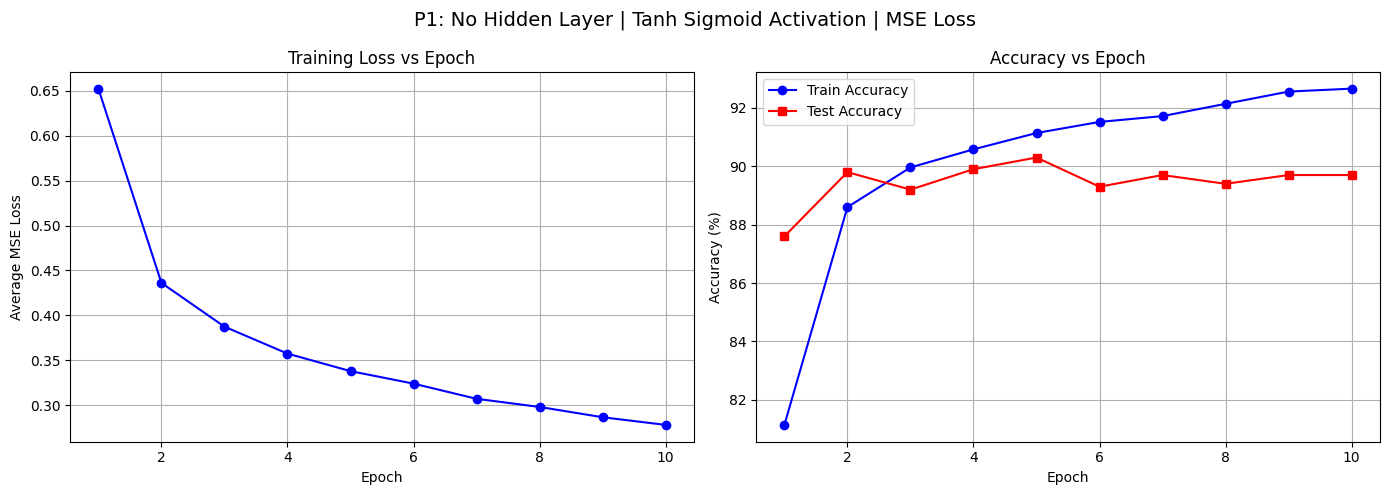


Final Train Accuracy: 92.66%
Final Test Accuracy:  89.70%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs+1), train_losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average MSE Loss')
ax1.set_title('Training Loss vs Epoch')
ax1.grid(True)

ax2.plot(range(1, epochs+1), train_accuracies, 'b-o', label='Train Accuracy')
ax2.plot(range(1, epochs+1), test_accuracies,  'r-s', label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy vs Epoch')
ax2.legend()
ax2.grid(True)

plt.suptitle('P1: No Hidden Layer | Tanh Sigmoid Activation | MSE Loss', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nFinal Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Test Accuracy:  {test_accuracies[-1]:.2f}%")